<a href="https://colab.research.google.com/github/AadityaBhure/Deep-Learning-Lab---7th-Semester/blob/main/prac5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Aaditya Bhure 23070521034
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
#Load Dataset
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [15]:
#Split Features and Target
X = df.drop("price", axis=1)
y = df["price"]

In [17]:
#Identify Numerical and Categorical Columns
numeric_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

In [ ]:
#Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Transform Data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [ ]:
#Create Model Function
def create_model(hidden_layers=2,
                 neurons=64,
                 activation='relu',
                 optimizer='adam'):

    model = Sequential()

    model.add(Dense(neurons,
                    activation=activation,
                    input_shape=(X_train.shape[1],)))

    for i in range(hidden_layers-1):
        model.add(Dense(neurons,
                        activation=activation))

    model.add(Dense(1))

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

In [ ]:
#Hyperparameter Experiments No. 1
model1 = create_model(
    hidden_layers=2,
    activation='relu',
    optimizer='adam'
)

history1 = model1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Hyperparameter Experiments No. 2
model2 = create_model(
    hidden_layers=3,
    activation='relu',
    optimizer='adam'
)

history2 = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=0
)

In [ ]:
#Hyperparameter Experiments No. 3
model3 = create_model(
    hidden_layers=3,
    activation='tanh',
    optimizer='rmsprop'
)

history3 = model3.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [ ]:
#Hyperparameter Experiments No. 4 (Different Lerarning rate)
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005
)

model4 = create_model(
    hidden_layers=4,
    activation='relu',
    optimizer=optimizer
)

history4 = model4.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    verbose=0
)

In [ ]:
#Evaluate Models
models = [model1, model2, model3, model4]

for i, model in enumerate(models, start=1):

    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    r2 = r2_score(y_test, pred)

    print(f"\nModel {i}")
    print("RMSE:", rmse)
    print("R²:", r2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Model 1
RMSE: 5306356.143560664
R²: -4.570684432983398
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step



Model 2
RMSE: 1365576.3250437523
R²: 0.6310667991638184
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Model 3
RMSE: 5489004.501329544
R²: -4.960777759552002
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Model 4
RMSE: 1625719.2472798002
R²: 0.477114200592041


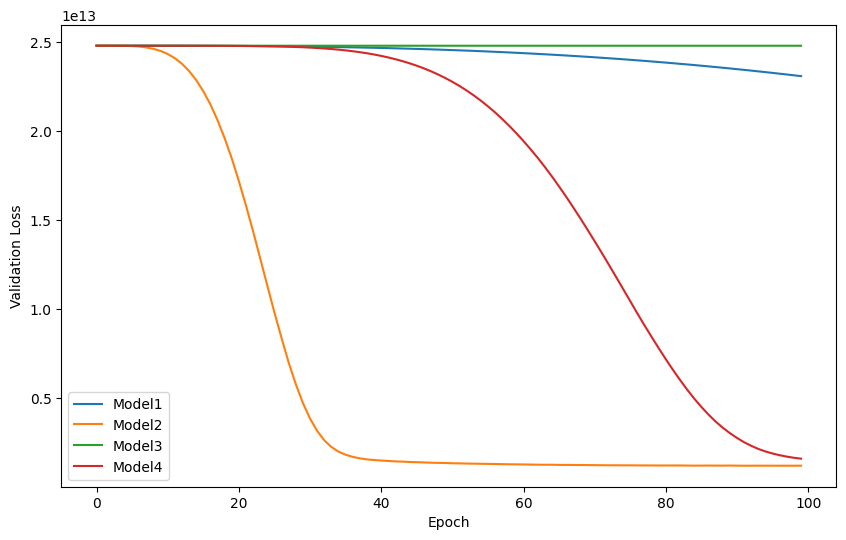

In [ ]:
#Compare Validation Loss
plt.figure(figsize=(10,6))

plt.plot(history1.history['val_loss'],label='Model1')
plt.plot(history2.history['val_loss'],label='Model2')
plt.plot(history3.history['val_loss'],label='Model3')
plt.plot(history4.history['val_loss'],label='Model4')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()

plt.show()